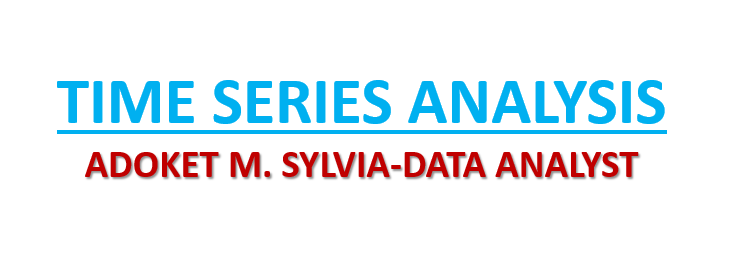

## **Importation of Libraries**

In [3]:
!pip install pmdarima

   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

data = pd.read_csv("murban.csv")
data.head()



,Months,crude_oil_prices
0,1/1/2003,29.60
1,2/1/2003,31.70
2,3/1/2003,29.10
3,4/1/2003,25.00
4,5/1/2003,25.85


### **Convert to datetime and set index (Assuming column 'Date' exists)**

In [5]:
data['Months'] = pd.to_datetime(data['Months'])
data.set_index('Months', inplace=True)

#### **Extract the series of interest**

In [6]:
crude = data['crude_oil_prices']

### **Plot time series**

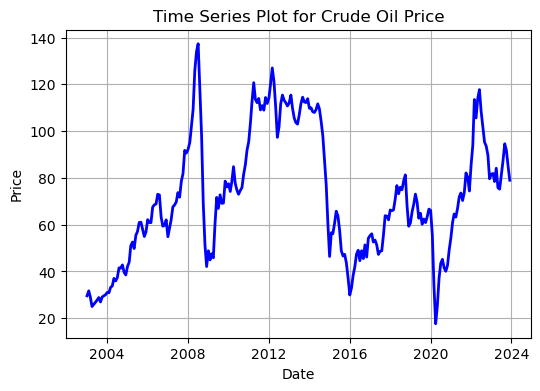

In [11]:
def plot_series(series, title="Time Series Plot for Crude Oil Price"):
    plt.figure(figsize=(6, 4))
    plt.plot(series, color='blue', linewidth=2)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.grid()
    plt.show()
plot_series(crude)

### **Check stationarity (Argumented Dickey-Fuller Test)**

Ho: The series is non stationary(Unit root)
H1: The series is stationary

In [12]:
def check_stationarity(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is non-stationary.")

check_stationarity(crude)

ADF Statistic: -2.8244483343412834
p-value: 0.054865468599675685
The series is non-stationary.


### **Differencing**

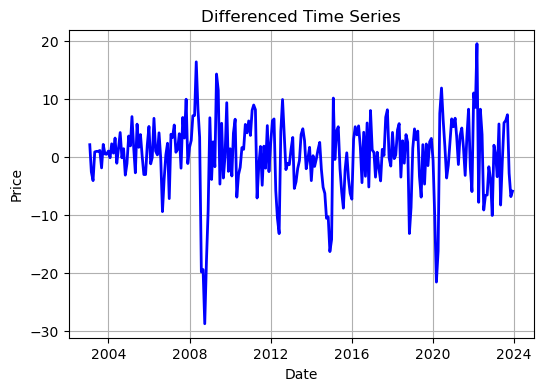

ADF Statistic: -8.934943433942943
p-value: 9.590447049349964e-15
The series is stationary.


In [13]:
crude_diff = crude.diff().dropna()
plot_series(crude_diff, title="Differenced Time Series")
check_stationarity(crude_diff)

### **Time Series Decomposition**

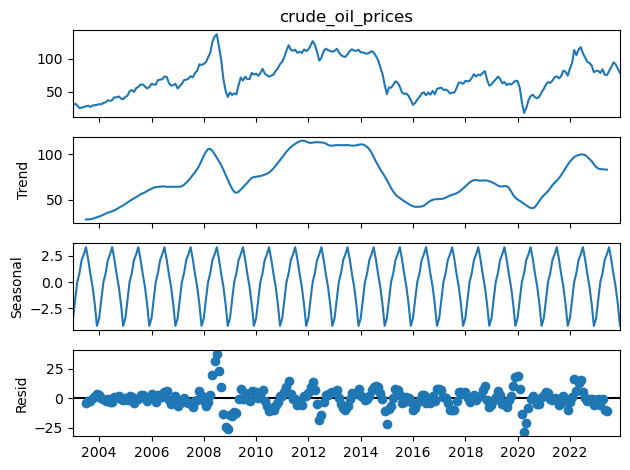

In [14]:
decomposition = seasonal_decompose(crude, model='additive', period=12)
decomposition.plot()
plt.show()

### **Plot ACF and PACF**

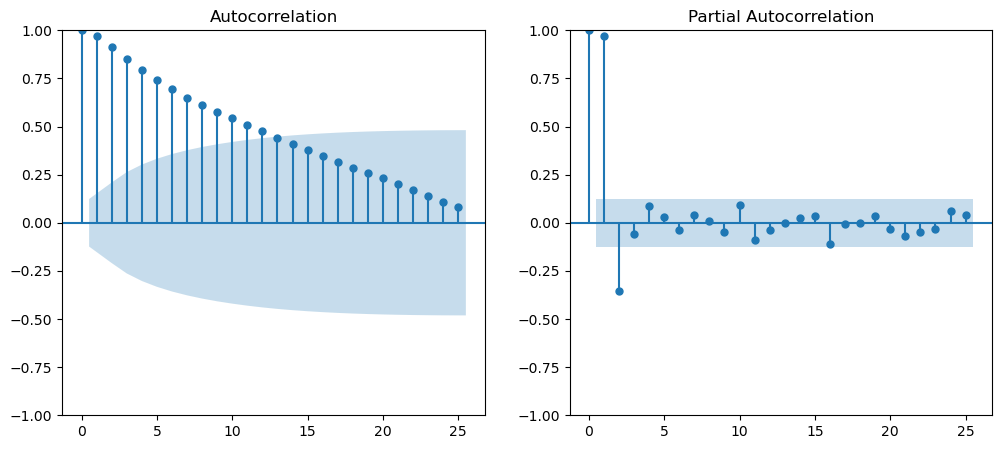

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(crude, ax=axes[0])
plot_pacf(crude, ax=axes[1])
plt.show()

### **Fit ARIMA model using auto_arima**

In [16]:
model = auto_arima(crude, seasonal=True, m=12, trace=True, suppress_warnings=True)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1598.325, Time=1.83 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1637.599, Time=0.09 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1597.562, Time=0.32 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1604.905, Time=0.38 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1635.846, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1595.941, Time=0.18 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1597.471, Time=0.32 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1599.020, Time=0.49 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1597.815, Time=0.17 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=1597.871, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1603.178, Time=0.16 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=1599.256, Time=0.52 sec
 ARIMA(1,1,0)(0,0,0)[12]             : AIC=1594.036, Time=0.08 sec
 ARIMA(1,1,0)(1,0,0)[12]             : AIC=1595.650, Time=0.15 sec
 ARIMA(1,1,0)(0,0,1

### **Fit and Forecast**

In [17]:
darima_model = ARIMA(crude, order=model.order).fit()
forecast_values = darima_model.forecast(steps=12)
forecast_values

2024-01-01    76.631158
2024-02-01    75.683284
2024-03-01    75.303999
2024-04-01    75.152232
2024-05-01    75.091503
2024-06-01    75.067203
2024-07-01    75.057479
2024-08-01    75.053589
2024-09-01    75.052032
2024-10-01    75.051409
2024-11-01    75.051160
2024-12-01    75.051060
Freq: MS, Name: predicted_mean, dtype: float64

### **Plot Forecast**

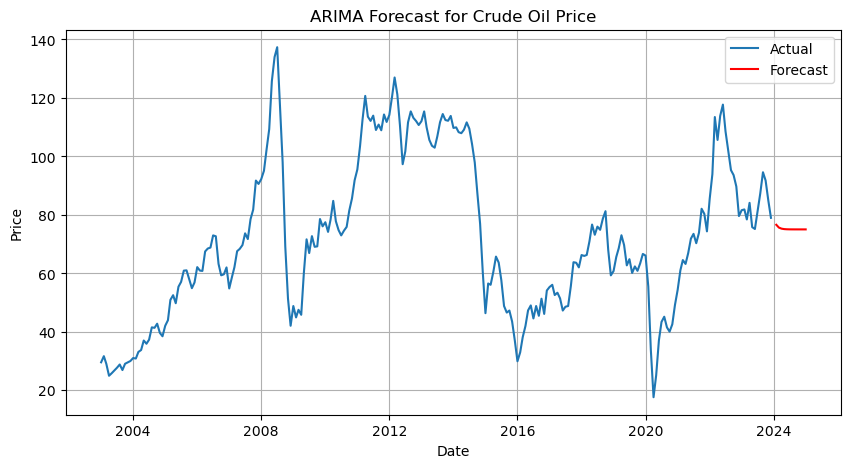

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(crude, label="Actual")
plt.plot(pd.date_range(crude.index[-1], periods=13, freq='ME')[1:], forecast_values, label="Forecast", color='red')
plt.title("ARIMA Forecast for Crude Oil Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()


In [21]:
def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)

    print(f"MAE  : {mae}")
    print(f"MSE  : {mse}")
    print(f"RMSE : {rmse}")
    
evaluate_forecast(crude[-12:], forecast_values)

MAE  : 7.711157757371467
MSE  : 93.00239664341996
RMSE : 9.643775020365208
